### **IMPORT LIBRARY**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **IMPORT DATASET**

In [5]:
df = pd.read_csv("movie_dataset.csv")

### **TOP**

In [7]:
df.head(1)

,title,budget,runtime,revenue
0,Movie 0,5.993428e+07,130.990332,1.376958e+08


### **Last**

In [9]:
df.tail(1)

,title,budget,runtime,revenue
1019,Movie 319,4.739714e+07,107.19543,1.028496e+08


### **SHAPE**

In [10]:
df.shape

(1020, 4)

In [11]:
df.size

4080

### **NULL**

In [12]:
df.isnull().sum()

title       0
budget     50
runtime    31
revenue    21
dtype: int64

### **FILL**

In [18]:
df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)


In [20]:
df.shape

(1020, 4)

### **DUPLICATE**

In [21]:
df.duplicated().any()

True

### **DROP DUPLICATE**

In [23]:
df.drop_duplicates(inplace = True)

In [24]:
df.duplicated().any()

False

In [25]:
df.shape

(1000, 4)

In [26]:
df = df.dropna(subset=['budget', 'revenue'])
print("Shape after dropping rows with missing budget or revenue:", df.shape)

Shape after dropping rows with missing budget or revenue: (1000, 4)


### **MEAN**

In [27]:
mean_runtime = df['runtime'].mean()
df['runtime'] = df['runtime'].fillna(mean_runtime)

In [28]:
mean_runtime

110.94445323526335

### **INFO**

In [29]:
print("\nCleaned dataset info:")
print(df.info())


Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   title    1000 non-null   object 
 1   budget   1000 non-null   float64
 2   runtime  1000 non-null   float64
 3   revenue  1000 non-null   float64
dtypes: float64(3), object(1)
memory usage: 39.1+ KB
None


### **DESCRIBE**

In [30]:
df.describe()

,budget,runtime,revenue
count,1.000000e+03,1000.000000,1.000000e+03
mean,5.037904e+07,110.944453,1.267733e+08
std,1.896256e+07,14.799441,5.104963e+07
min,5.000000e+06,65.894170,1.123053e+07
25%,3.801241e+07,100.976319,9.040468e+07
50%,5.031806e+07,110.914117,1.261246e+08
75%,6.244140e+07,120.447938,1.601196e+08
max,1.270546e+08,157.896614,3.176096e+08


# 2. Scatter Plot: Budget vs Revenue

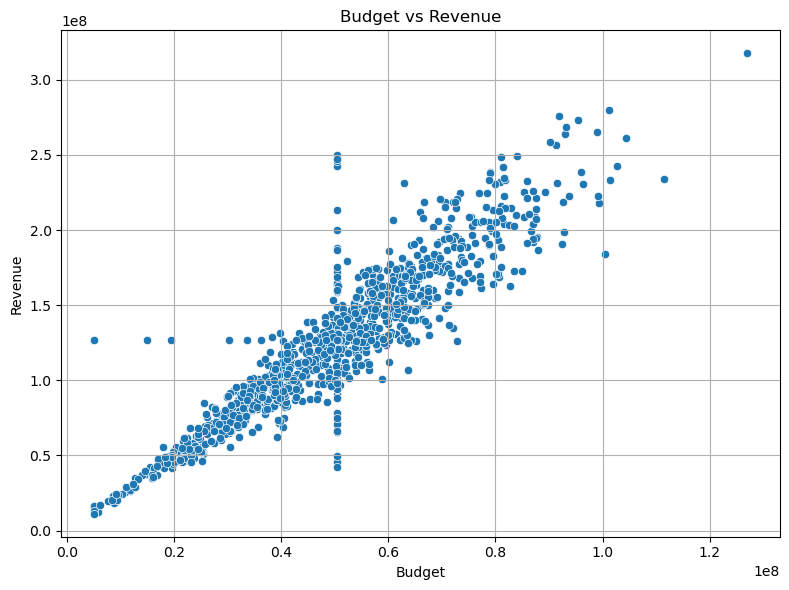

In [31]:

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='budget', y='revenue')
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Correlation Matrix

In [33]:

correlation_matrix = df[['budget', 'runtime', 'revenue']].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
           budget   runtime   revenue
budget   1.000000 -0.047315  0.915961
runtime -0.047315  1.000000 -0.034255
revenue  0.915961 -0.034255  1.000000


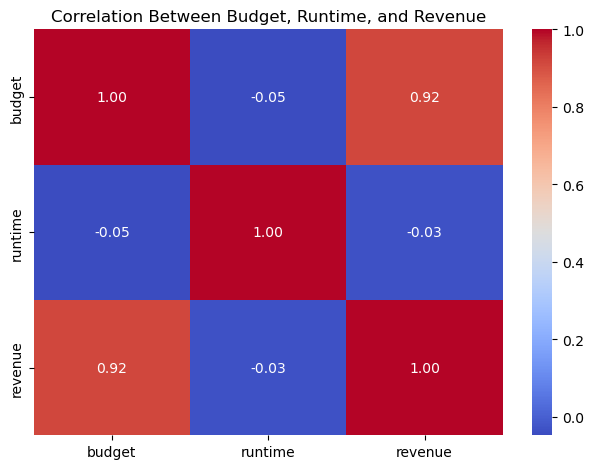

In [36]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Budget, Runtime, and Revenue")
plt.tight_layout()
plt.show()

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# 1. Select Features and Target
X = df[['budget']]   # Feature as a DataFrame
y = df['revenue']    # Target as a Series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm the split
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (800, 1)
Testing data shape: (200, 1)


In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load and clean the data
df = pd.read_csv("movie_dataset.csv")
df = df.drop_duplicates()
df = df.dropna(subset=['budget', 'revenue'])
df['runtime'] = df['runtime'].fillna(df['runtime'].mean())

# Select features and target
X = df[['budget']]
y = df['revenue']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Predict using test data
y_pred = model.predict(X_test)

# 3. Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 4. Print metrics
print("Model Evaluation Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")



Model Evaluation Metrics:
R² Score: 0.8888
Mean Absolute Error (MAE): 13047758.03
Mean Squared Error (MSE): 310822555366898.31
Root Mean Squared Error (RMSE): 17630160.39


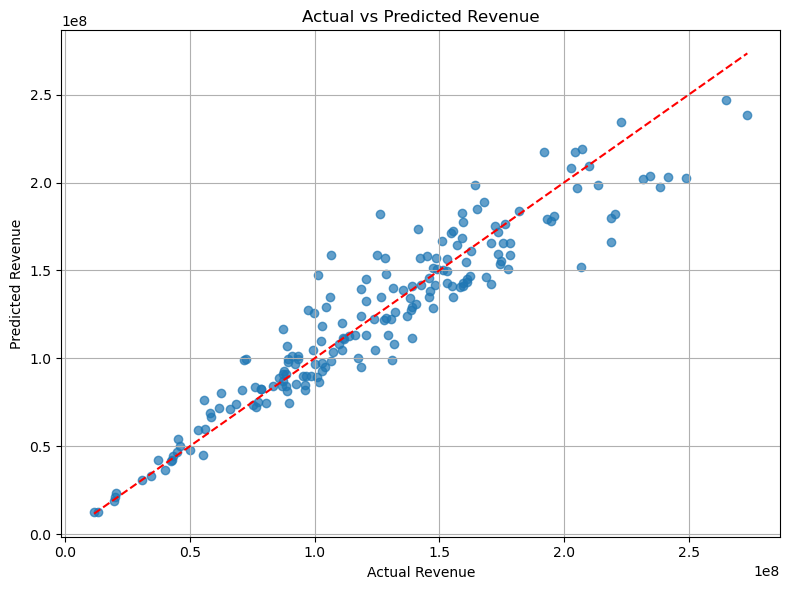

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.grid(True)
plt.tight_layout()
plt.show()


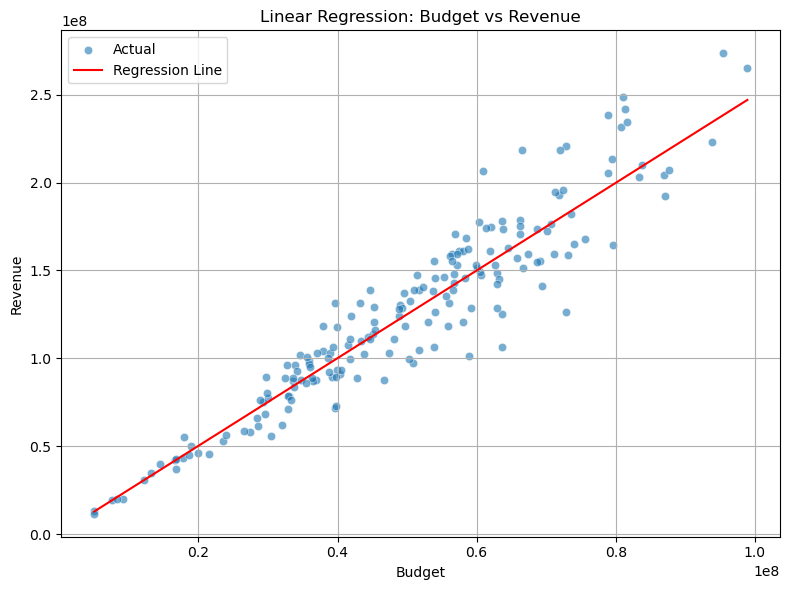

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the data points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test['budget'], y=y_test, label='Actual', alpha=0.6)

# Plot the regression line
sns.lineplot(x=X_test['budget'], y=y_pred, color='red', label='Regression Line')

# Labels and title
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Linear Regression: Budget vs Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
